# Stats of features:
She said, she said - The Beatles


## 5 min labeling (ictal vs. pre-ictal)

### 1. Load df with features: Ictal vs. preictal 5min

In [4]:
import pandas as pd

df_feat_ictalVspreictal_5min = pd.read_pickle("/home/tperezsanchez/FoundationModel_EEG_Dissertation/Main_project/results/XB47Y/Feature_ext/Part2_features/df_features_ictal_Vs_Preictal.pkl")

print(df_feat_ictalVspreictal_5min.head())


                   file_name  window_id  start_sample  end_sample          fs  \
0  XB47Y_41_preproc_full.npz       1254       2595780     2597850  207.031055   
1  XB47Y_41_preproc_full.npz       1255       2597850     2599920  207.031055   
2  XB47Y_41_preproc_full.npz       1256       2599920     2601990  207.031055   
3  XB47Y_41_preproc_full.npz       1257       2601990     2604060  207.031055   
4  XB47Y_41_preproc_full.npz       1258       2604060     2606130  207.031055   

   n_channels  window_sec                seizure_onsets  \
0           2          10  [2019-10-31 23:25:08.153000]   
1           2          10  [2019-10-31 23:25:08.153000]   
2           2          10  [2019-10-31 23:25:08.153000]   
3           2          10  [2019-10-31 23:25:08.153000]   
4           2          10  [2019-10-31 23:25:08.153000]   

              window_start_time               window_end_time  ...  \
0 2019-10-31 23:15:03.118999591 2019-10-31 23:15:13.117499590  ...   
1 2019-10-31 23:15

In [13]:
  #  "interictal": 0,
  #  "preictal": 1,
  #  "seizure": 2
# Group 1: preictal windows
group_1_PREICTAL = df_feat_ictalVspreictal_5min[df_feat_ictalVspreictal_5min["class_label"] == 1].copy()

# Group 2: seizure windows
group_2_SEIZURE = df_feat_ictalVspreictal_5min[df_feat_ictalVspreictal_5min["class_label"] == 2].copy()

print("Shape of group 1 preictal:", group_1_PREICTAL.shape)
print("Shape of group 2 seizure:", group_2_SEIZURE.shape)

#Shape of group 0: (1047, 41)
#Shape of group 1: (1102, 41)

Shape of group 1 preictal: (1047, 41)
Shape of group 2 seizure: (1102, 41)


In [8]:
df_feat_ictalVspreictal_5min["peak_frequency_EEG_SQ_D_SQ_C"].describe()

count    2149.000000
mean        1.367818
std         2.963405
min         0.500075
25%         1.000150
50%         1.000150
75%         1.000150
max        39.505926
Name: peak_frequency_EEG_SQ_D_SQ_C, dtype: float64

In [14]:
group_1_PREICTAL.head()

,file_name,window_id,start_sample,end_sample,fs,n_channels,window_sec,seizure_onsets,window_start_time,window_end_time,...,alpha_power_EEG_SQ_D_SQ_C,beta_power_EEG_SQ_D_SQ_C,gamma_power_EEG_SQ_D_SQ_C,peak_frequency_EEG_SQ_D_SQ_C,delta_power_EEG_SQ_P_SQ_C,theta_power_EEG_SQ_P_SQ_C,alpha_power_EEG_SQ_P_SQ_C,beta_power_EEG_SQ_P_SQ_C,gamma_power_EEG_SQ_P_SQ_C,peak_frequency_EEG_SQ_P_SQ_C
0,XB47Y_41_preproc_full.npz,1254,2595780,2597850,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:15:03.118999591,2019-10-31 23:15:13.117499590,...,0.003656,0.034655,0.018155,1.00015,0.160633,0.008688,0.008652,0.033698,0.021094,1.00015
1,XB47Y_41_preproc_full.npz,1255,2597850,2599920,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:15:13.117499590,2019-10-31 23:15:23.115999590,...,0.034949,0.066192,0.024481,1.00015,1.160761,0.058562,0.066291,0.911522,0.171770,1.00015
2,XB47Y_41_preproc_full.npz,1256,2599920,2601990,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:15:23.115999590,2019-10-31 23:15:33.114499590,...,0.001955,0.038650,0.011128,1.00015,0.086239,0.006419,0.004891,0.055154,0.029888,1.00015
3,XB47Y_41_preproc_full.npz,1257,2601990,2604060,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:15:33.114499590,2019-10-31 23:15:43.112999590,...,0.002152,0.039139,0.012537,1.00015,0.074514,0.006131,0.007192,0.052075,0.028502,1.00015
4,XB47Y_41_preproc_full.npz,1258,2604060,2606130,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:15:43.112999590,2019-10-31 23:15:53.111499589,...,0.002427,0.062461,0.022991,1.00015,0.032069,0.003982,0.010966,0.093744,0.045717,1.00015


In [11]:
import numpy as np

# Select only numeric columns
numeric_cols = df_feat_ictalVspreictal_5min.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric columns:")
print(numeric_cols)
print("Number of numeric columns:", len(numeric_cols))

Numeric columns:
['window_id', 'start_sample', 'end_sample', 'fs', 'n_channels', 'window_sec', 'class_label', 'mean_EEG_SQ_D_SQ_C', 'std_EEG_SQ_D_SQ_C', 'var_EEG_SQ_D_SQ_C', 'rms_EEG_SQ_D_SQ_C', 'ptp_EEG_SQ_D_SQ_C', 'line_length_EEG_SQ_D_SQ_C', 'skew_EEG_SQ_D_SQ_C', 'kurtosis_EEG_SQ_D_SQ_C', 'mean_EEG_SQ_P_SQ_C', 'std_EEG_SQ_P_SQ_C', 'var_EEG_SQ_P_SQ_C', 'rms_EEG_SQ_P_SQ_C', 'ptp_EEG_SQ_P_SQ_C', 'line_length_EEG_SQ_P_SQ_C', 'skew_EEG_SQ_P_SQ_C', 'kurtosis_EEG_SQ_P_SQ_C', 'delta_power_EEG_SQ_D_SQ_C', 'theta_power_EEG_SQ_D_SQ_C', 'alpha_power_EEG_SQ_D_SQ_C', 'beta_power_EEG_SQ_D_SQ_C', 'gamma_power_EEG_SQ_D_SQ_C', 'peak_frequency_EEG_SQ_D_SQ_C', 'delta_power_EEG_SQ_P_SQ_C', 'theta_power_EEG_SQ_P_SQ_C', 'alpha_power_EEG_SQ_P_SQ_C', 'beta_power_EEG_SQ_P_SQ_C', 'gamma_power_EEG_SQ_P_SQ_C', 'peak_frequency_EEG_SQ_P_SQ_C']
Number of numeric columns: 35


In [22]:
# Numeric columns that are metadata or not real signal features
exclude_cols = [
    "window_id",
    "start_sample",
    "end_sample",
    "fs",
    "n_channels",
    "class_label",
    "window_sec"
]

# Keep only true numeric feature columns
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print("Feature columns:")
print(feature_cols)
print("Number of feature columns:", len(feature_cols))

Feature columns:
['mean_EEG_SQ_D_SQ_C', 'std_EEG_SQ_D_SQ_C', 'var_EEG_SQ_D_SQ_C', 'rms_EEG_SQ_D_SQ_C', 'ptp_EEG_SQ_D_SQ_C', 'line_length_EEG_SQ_D_SQ_C', 'skew_EEG_SQ_D_SQ_C', 'kurtosis_EEG_SQ_D_SQ_C', 'mean_EEG_SQ_P_SQ_C', 'std_EEG_SQ_P_SQ_C', 'var_EEG_SQ_P_SQ_C', 'rms_EEG_SQ_P_SQ_C', 'ptp_EEG_SQ_P_SQ_C', 'line_length_EEG_SQ_P_SQ_C', 'skew_EEG_SQ_P_SQ_C', 'kurtosis_EEG_SQ_P_SQ_C', 'delta_power_EEG_SQ_D_SQ_C', 'theta_power_EEG_SQ_D_SQ_C', 'alpha_power_EEG_SQ_D_SQ_C', 'beta_power_EEG_SQ_D_SQ_C', 'gamma_power_EEG_SQ_D_SQ_C', 'peak_frequency_EEG_SQ_D_SQ_C', 'delta_power_EEG_SQ_P_SQ_C', 'theta_power_EEG_SQ_P_SQ_C', 'alpha_power_EEG_SQ_P_SQ_C', 'beta_power_EEG_SQ_P_SQ_C', 'gamma_power_EEG_SQ_P_SQ_C', 'peak_frequency_EEG_SQ_P_SQ_C']
Number of feature columns: 28


In [23]:
feature_cols

['mean_EEG_SQ_D_SQ_C',
 'std_EEG_SQ_D_SQ_C',
 'var_EEG_SQ_D_SQ_C',
 'rms_EEG_SQ_D_SQ_C',
 'ptp_EEG_SQ_D_SQ_C',
 'line_length_EEG_SQ_D_SQ_C',
 'skew_EEG_SQ_D_SQ_C',
 'kurtosis_EEG_SQ_D_SQ_C',
 'mean_EEG_SQ_P_SQ_C',
 'std_EEG_SQ_P_SQ_C',
 'var_EEG_SQ_P_SQ_C',
 'rms_EEG_SQ_P_SQ_C',
 'ptp_EEG_SQ_P_SQ_C',
 'line_length_EEG_SQ_P_SQ_C',
 'skew_EEG_SQ_P_SQ_C',
 'kurtosis_EEG_SQ_P_SQ_C',
 'delta_power_EEG_SQ_D_SQ_C',
 'theta_power_EEG_SQ_D_SQ_C',
 'alpha_power_EEG_SQ_D_SQ_C',
 'beta_power_EEG_SQ_D_SQ_C',
 'gamma_power_EEG_SQ_D_SQ_C',
 'peak_frequency_EEG_SQ_D_SQ_C',
 'delta_power_EEG_SQ_P_SQ_C',
 'theta_power_EEG_SQ_P_SQ_C',
 'alpha_power_EEG_SQ_P_SQ_C',
 'beta_power_EEG_SQ_P_SQ_C',
 'gamma_power_EEG_SQ_P_SQ_C',
 'peak_frequency_EEG_SQ_P_SQ_C']

### 2. Box-plots + mann whitney:

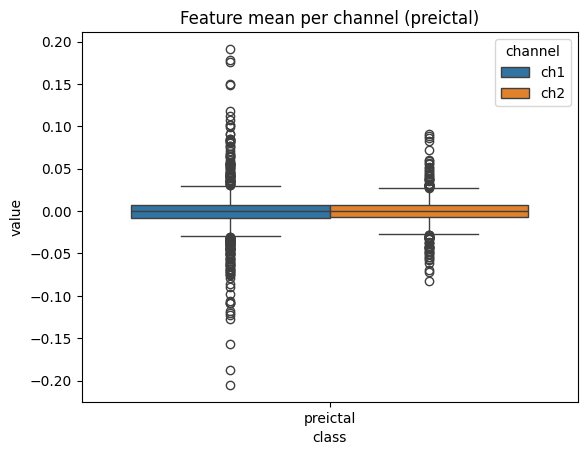

In [20]:
# TEST with only one feature
feat_ch1 = "mean_EEG_SQ_D_SQ_C"
feat_ch2 = "mean_EEG_SQ_P_SQ_C"

df_boxplot_PREICTAL_test_MEAN = pd.DataFrame({
    "value": pd.concat([group_1_PREICTAL[feat_ch1], group_1_PREICTAL[feat_ch2]], axis=0),
    "channel": ["ch1"] * len(group_1_PREICTAL) + ["ch2"] * len(group_1_PREICTAL),
    "class": pd.concat([group_1_PREICTAL["class_label"], group_1_PREICTAL["class_label"]], axis=0)
})
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df_boxplot_PREICTAL_test_MEAN,
    x="class",
    y="value",
    hue="channel"
)

plt.xticks([0], ["preictal"])  
plt.title("Feature mean per channel (preictal)")
plt.show()

#### 2.1 Test box-plot. Per feature comparission by group (ictal vs. preictal)

In [26]:
# Imports + configuración + sanity check
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# -------------------------------
# Parameters
# -------------------------------
alpha = 0.05
# difference is significative when : p_value < 0.05
# -------------------------------
# Sanity checks
# -------------------------------

# Check that feature_cols exists and is not empty
print("Number of feature columns:", len(feature_cols))

# Check dataframe shapes
print("Preictal dataframe shape:", group_1_PREICTAL.shape)
print("Seizure dataframe shape:", group_2_SEIZURE.shape)

# Check first few feature columns
print("\nFirst 5 feature columns:")
print(feature_cols[:5])

# -------------------------------
# Check that all feature columns exist in both dataframes
# -------------------------------

missing_in_preictal = [col for col in feature_cols if col not in group_1_PREICTAL.columns]
missing_in_seizure = [col for col in feature_cols if col not in group_2_SEIZURE.columns]

print("Features missing in PREICTAL dataframe:", len(missing_in_preictal))
print("Features missing in SEIZURE dataframe:", len(missing_in_seizure))

if len(missing_in_preictal) > 0:
    print("\nMissing in PREICTAL:")
    print(missing_in_preictal)

if len(missing_in_seizure) > 0:
    print("\nMissing in SEIZURE:")
    print(missing_in_seizure)

if len(missing_in_preictal) == 0 and len(missing_in_seizure) == 0:
    print("\nAll feature columns are present in both dataframes ✔️")


Number of feature columns: 28
Preictal dataframe shape: (1047, 41)
Seizure dataframe shape: (1102, 41)

First 5 feature columns:
['mean_EEG_SQ_D_SQ_C', 'std_EEG_SQ_D_SQ_C', 'var_EEG_SQ_D_SQ_C', 'rms_EEG_SQ_D_SQ_C', 'ptp_EEG_SQ_D_SQ_C']
Features missing in PREICTAL dataframe: 0
Features missing in SEIZURE dataframe: 0

All feature columns are present in both dataframes ✔️


Testing feature: mean_EEG_SQ_D_SQ_C
Number of preictal values: 1047
Number of seizure values: 1102

First preictal values:
0    0.008743
1   -0.003641
2   -0.000685
3   -0.005067
4   -0.008477
Name: mean_EEG_SQ_D_SQ_C, dtype: float32

First seizure values:
31   -0.036055
32    0.035934
33    0.022185
34   -0.028162
35    0.005231
Name: mean_EEG_SQ_D_SQ_C, dtype: float32
      value     label
0  0.008743  preictal
1 -0.003641  preictal
2 -0.000685  preictal
3 -0.005067  preictal
4 -0.008477  preictal

Shape of df_plot: (2149, 2)

Label counts:
label
seizure     1102
preictal    1047
Name: count, dtype: int64


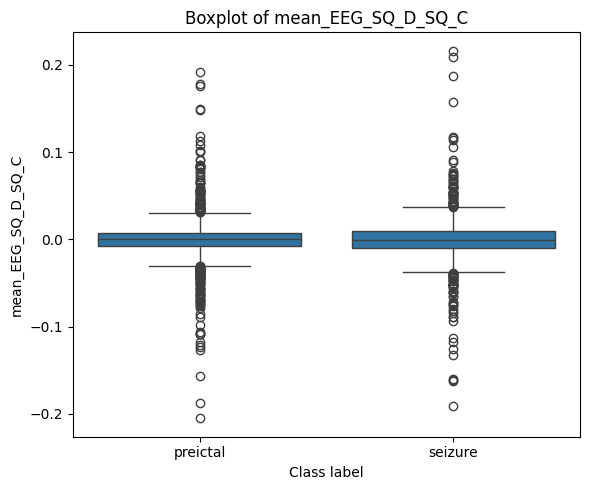

In [30]:
# -------------------------------
# Select one feature to test
# -------------------------------

feature = feature_cols[0]

print("Testing feature:", feature)
# -------------------------------
# Extract values for that feature from each label group
# -------------------------------

preictal_values = group_1_PREICTAL[feature].dropna()
seizure_values = group_2_SEIZURE[feature].dropna()

print("Number of preictal values:", len(preictal_values))
print("Number of seizure values:", len(seizure_values))

print("\nFirst preictal values:")
print(preictal_values.head())

print("\nFirst seizure values:")
print(seizure_values.head())

# -------------------------------
# Create long-format dataframe for plotting
# -------------------------------

df_plot = pd.DataFrame({
    "value": pd.concat([preictal_values, seizure_values], axis=0),
    "label": (
        ["preictal"] * len(preictal_values) +
        ["seizure"] * len(seizure_values)
    )
})

print(df_plot.head())
print("\nShape of df_plot:", df_plot.shape)
print("\nLabel counts:")
print(df_plot["label"].value_counts())

# -------------------------------
# Boxplot for one feature
# -------------------------------

plt.figure(figsize=(6, 5))

sns.boxplot(
    data=df_plot,
    x="label",
    y="value"
)

plt.title(f"Boxplot of {feature}")
plt.xlabel("Class label")
plt.ylabel(feature)

plt.tight_layout()
plt.show()

Feature: mean_EEG_SQ_D_SQ_C
Mann-Whitney U statistic: 582146.0
p-value: 0.7150802878564748
Result: No significant difference between preictal and seizure


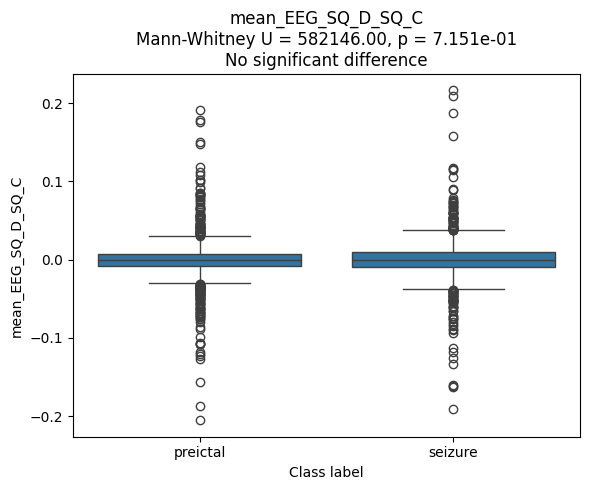

In [33]:
# -------------------------------
# Mann-Whitney U test for one feature
# -------------------------------

stat, p_value = mannwhitneyu(
    preictal_values,
    seizure_values,
    alternative="two-sided"
)

print("Feature:", feature)
print("Mann-Whitney U statistic:", stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Result: Significant difference between preictal and seizure")
else:
    print("Result: No significant difference between preictal and seizure")
    # -------------------------------
# Boxplot + Mann-Whitney result in title
# -------------------------------

if p_value < alpha:
    test_result = "Significant difference"
else:
    test_result = "No significant difference"

plt.figure(figsize=(6, 5))

sns.boxplot(
    data=df_plot,
    x="label",
    y="value"
)

plt.title(
    f"{feature}\n"
    f"Mann-Whitney U = {stat:.2f}, p = {p_value:.3e}\n"
    f"{test_result}"
)

plt.xlabel("Class label")
plt.ylabel(feature)

plt.tight_layout()
plt.show()


#### 2.2 Box-plot + Mann-W. of all features
plots by feature per category (ictal vs. preictal)

Plotting feature: mean_EEG_SQ_D_SQ_C


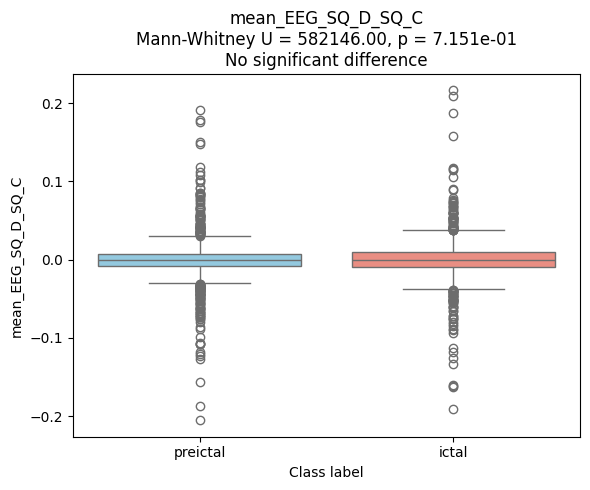

Plotting feature: std_EEG_SQ_D_SQ_C


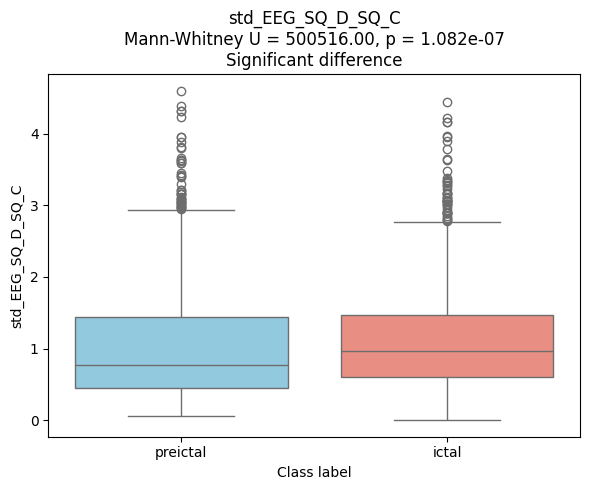

Plotting feature: var_EEG_SQ_D_SQ_C


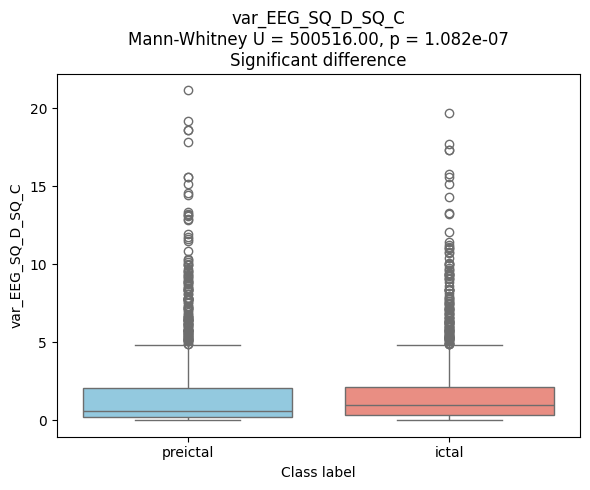

Plotting feature: rms_EEG_SQ_D_SQ_C


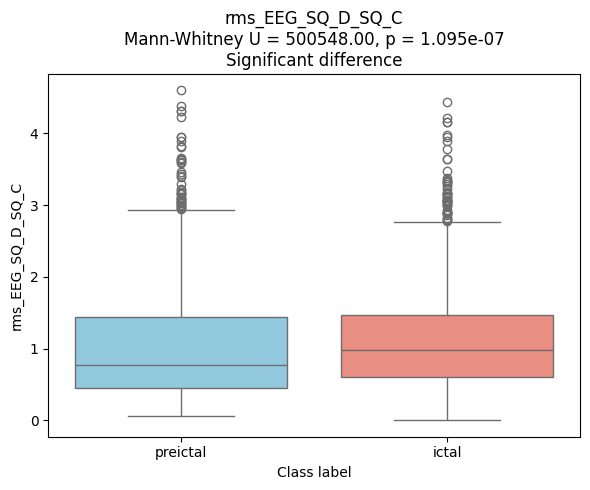

Plotting feature: ptp_EEG_SQ_D_SQ_C


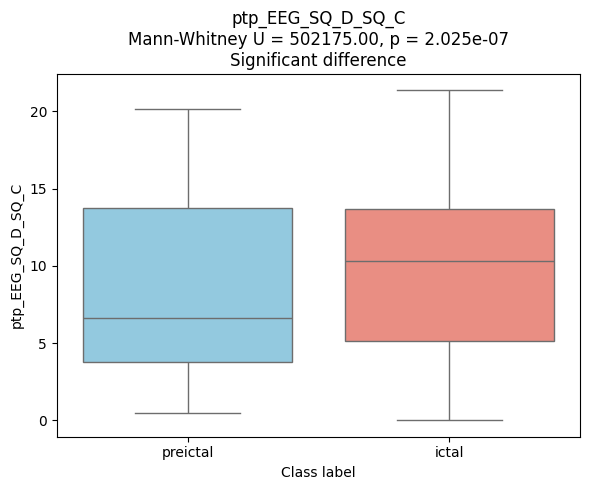

Plotting feature: line_length_EEG_SQ_D_SQ_C


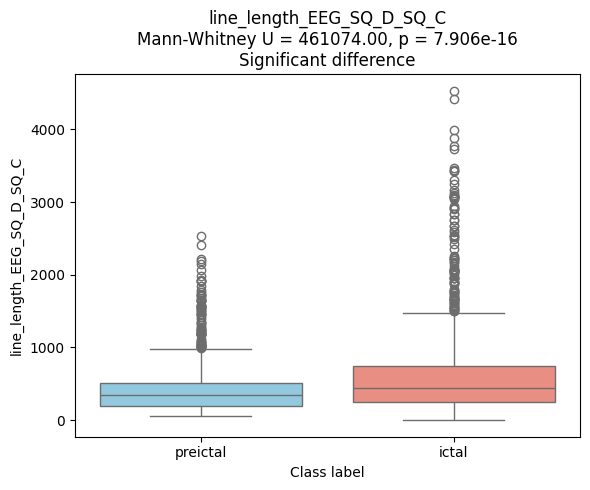

Plotting feature: skew_EEG_SQ_D_SQ_C


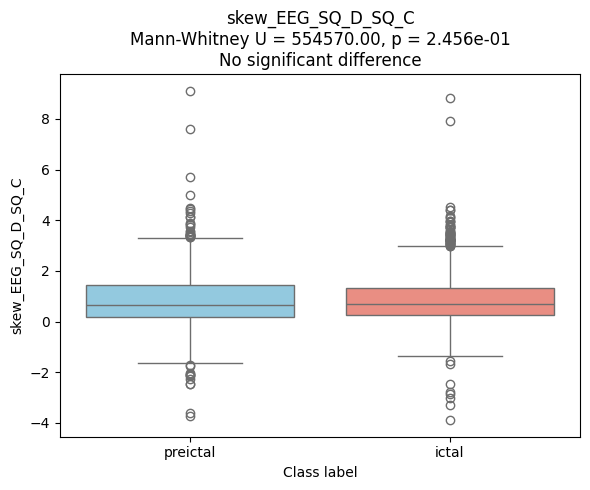

Plotting feature: kurtosis_EEG_SQ_D_SQ_C


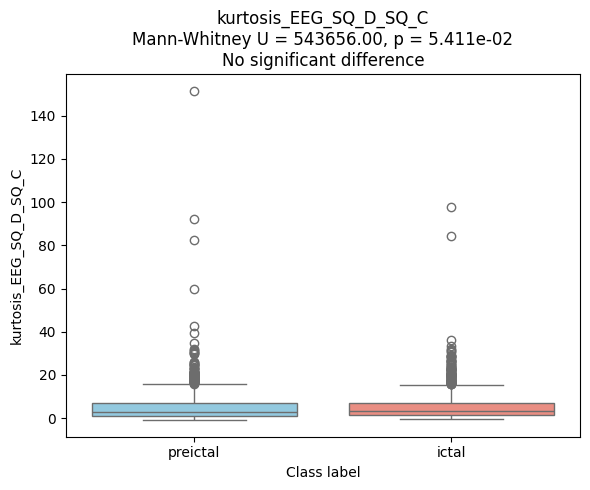

Plotting feature: mean_EEG_SQ_P_SQ_C


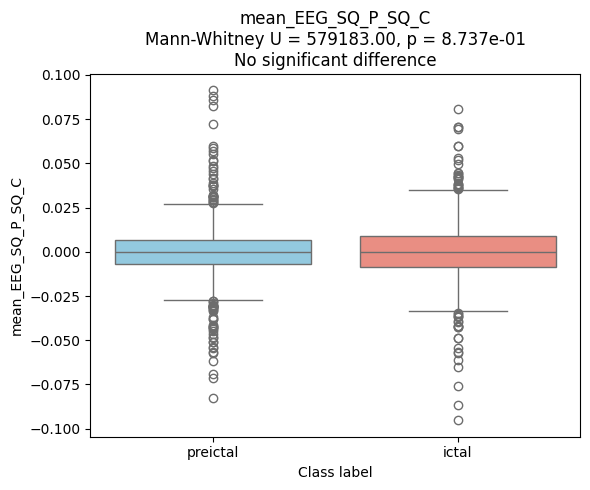

Plotting feature: std_EEG_SQ_P_SQ_C


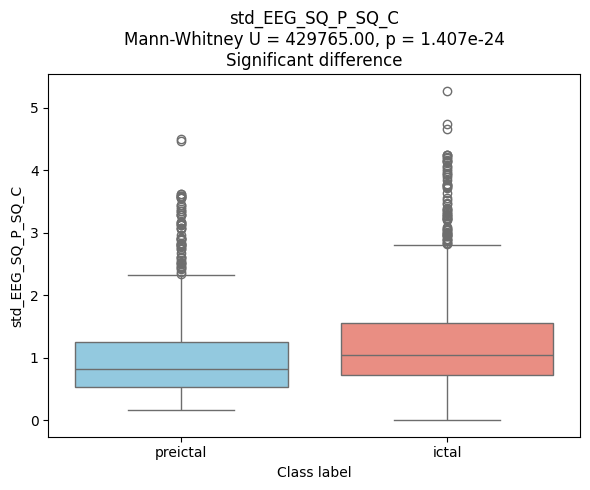

Plotting feature: var_EEG_SQ_P_SQ_C


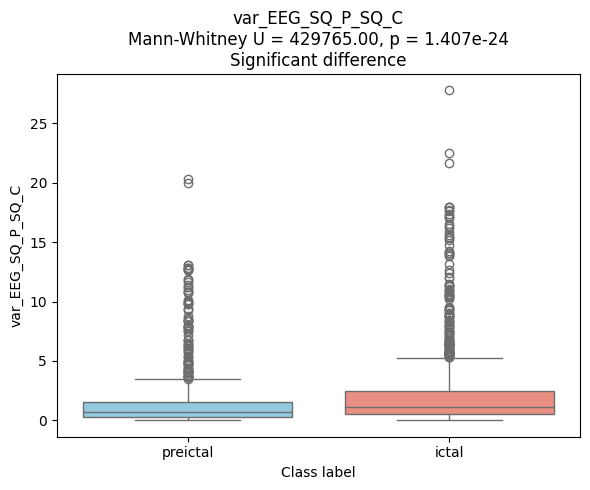

Plotting feature: rms_EEG_SQ_P_SQ_C


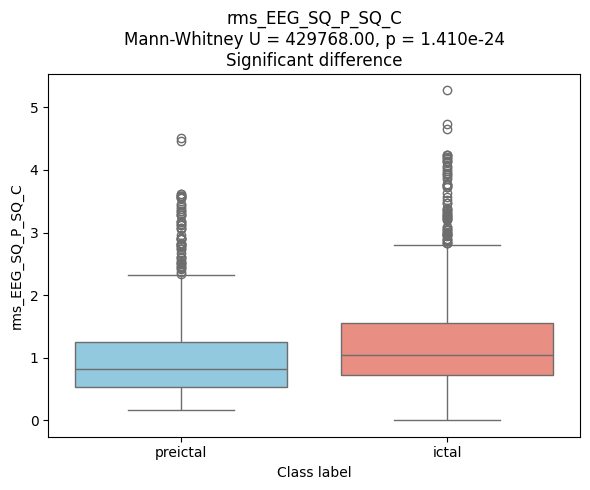

Plotting feature: ptp_EEG_SQ_P_SQ_C


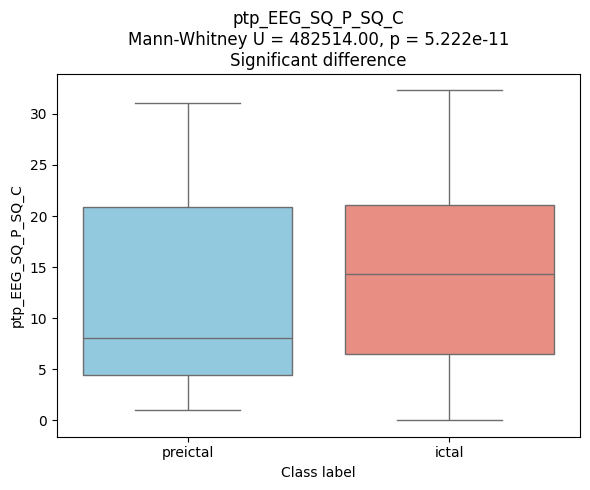

Plotting feature: line_length_EEG_SQ_P_SQ_C


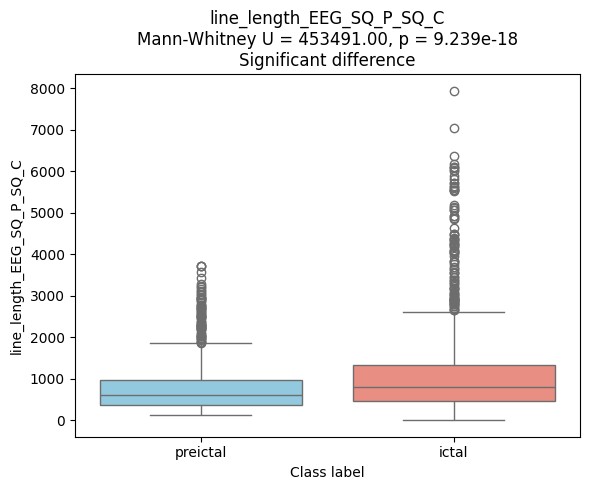

Plotting feature: skew_EEG_SQ_P_SQ_C


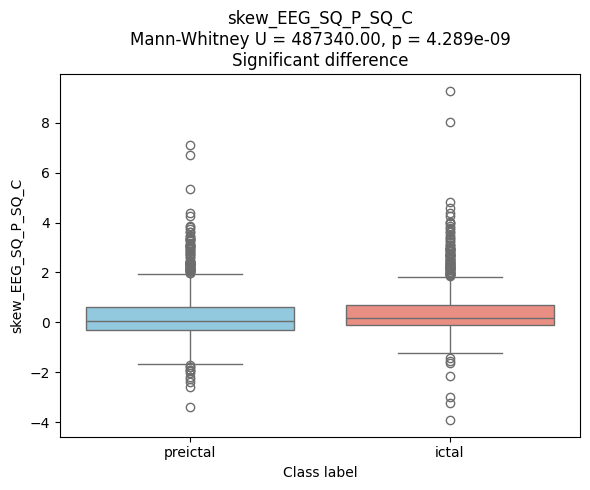

Plotting feature: kurtosis_EEG_SQ_P_SQ_C


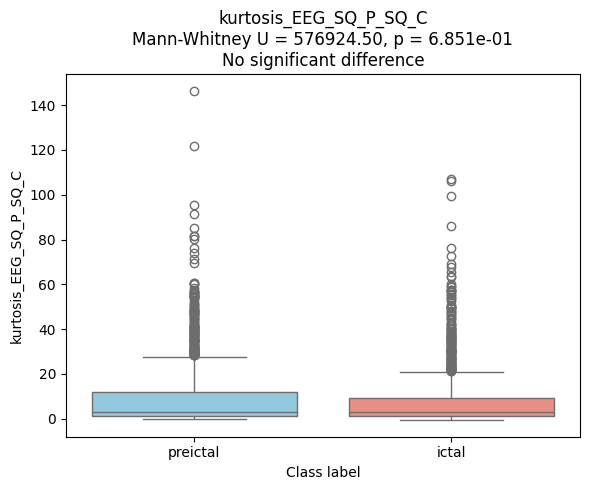

Plotting feature: delta_power_EEG_SQ_D_SQ_C


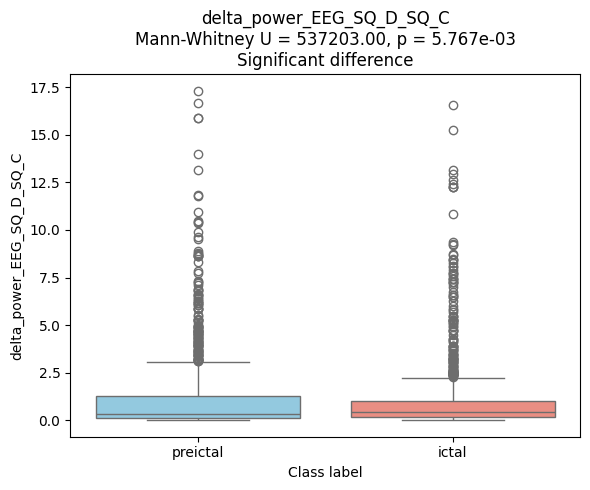

Plotting feature: theta_power_EEG_SQ_D_SQ_C


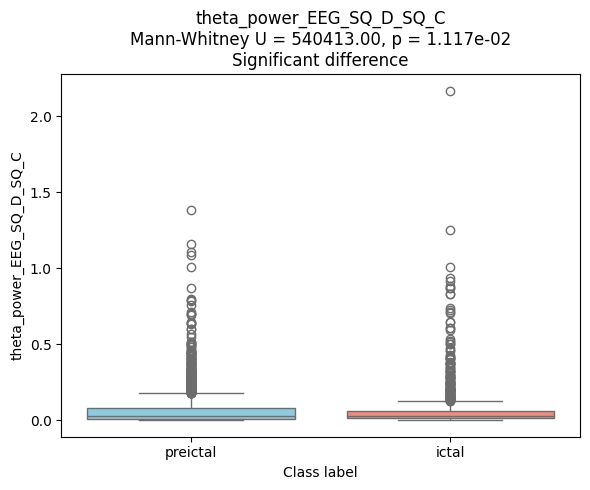

Plotting feature: alpha_power_EEG_SQ_D_SQ_C


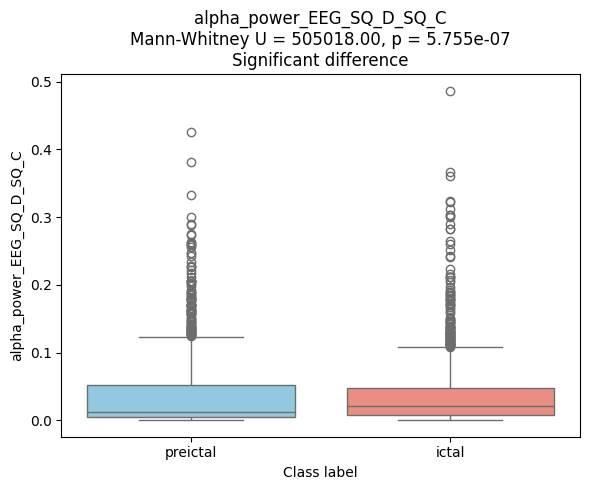

Plotting feature: beta_power_EEG_SQ_D_SQ_C


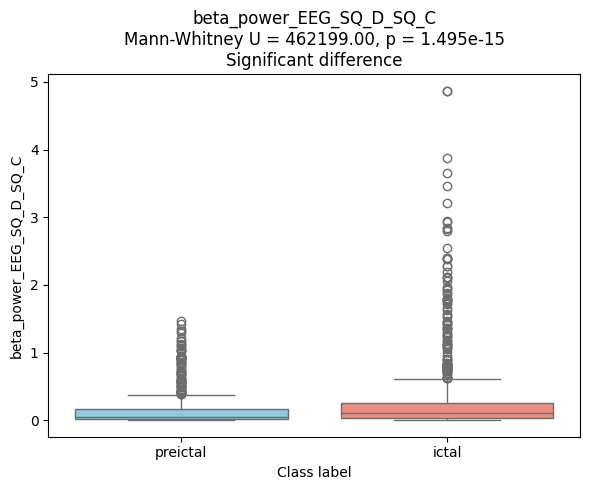

Plotting feature: gamma_power_EEG_SQ_D_SQ_C


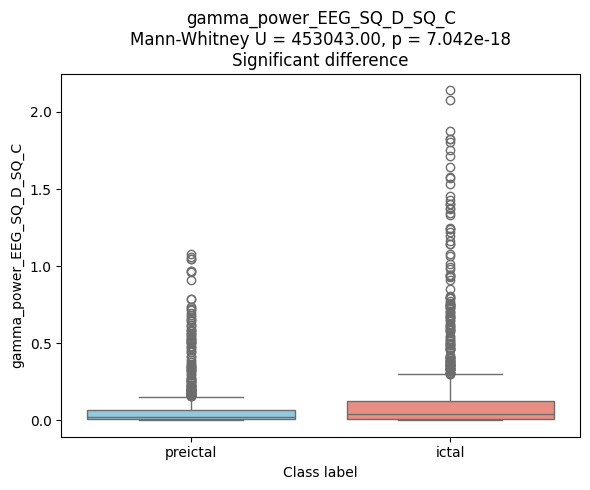

Plotting feature: peak_frequency_EEG_SQ_D_SQ_C


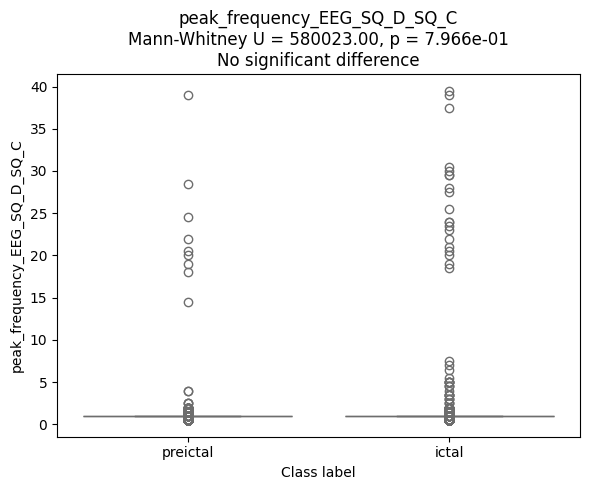

Plotting feature: delta_power_EEG_SQ_P_SQ_C


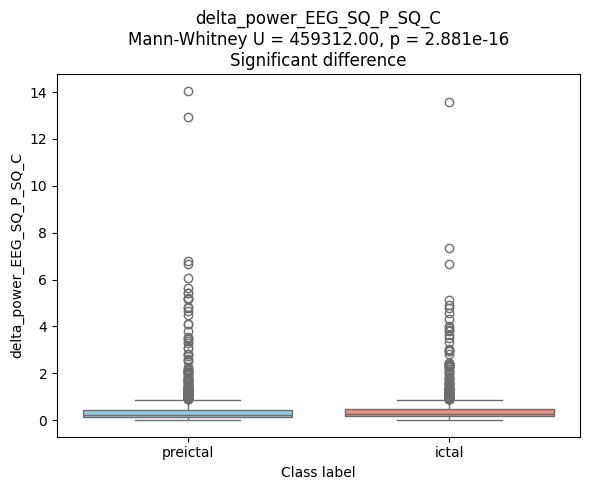

Plotting feature: theta_power_EEG_SQ_P_SQ_C


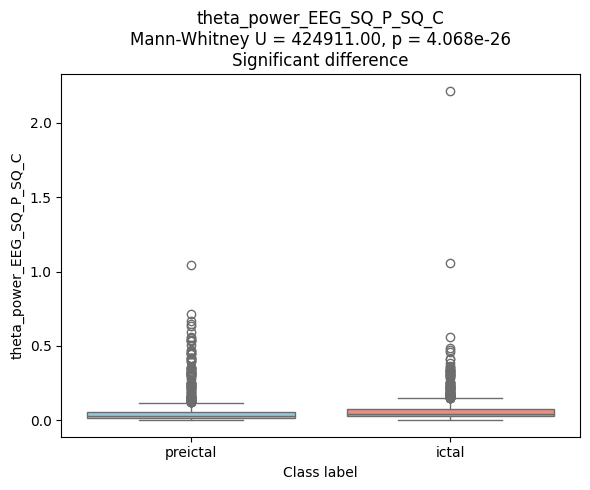

Plotting feature: alpha_power_EEG_SQ_P_SQ_C


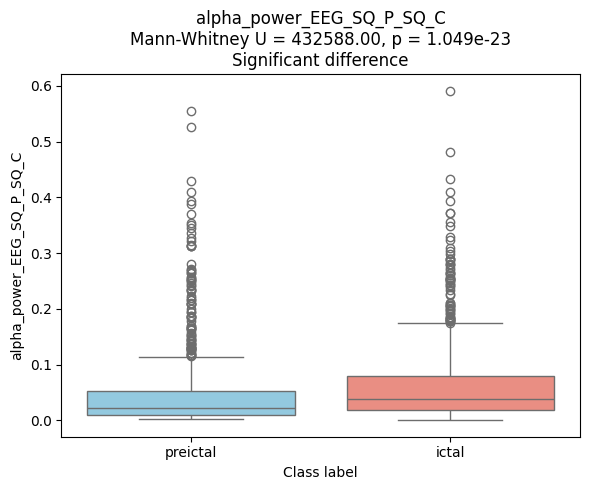

Plotting feature: beta_power_EEG_SQ_P_SQ_C


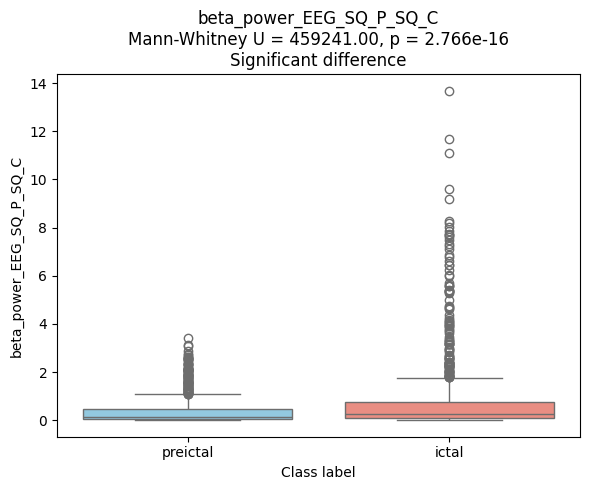

Plotting feature: gamma_power_EEG_SQ_P_SQ_C


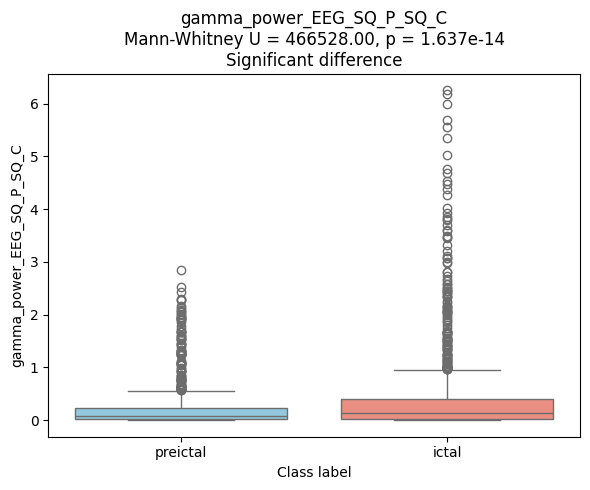

Plotting feature: peak_frequency_EEG_SQ_P_SQ_C


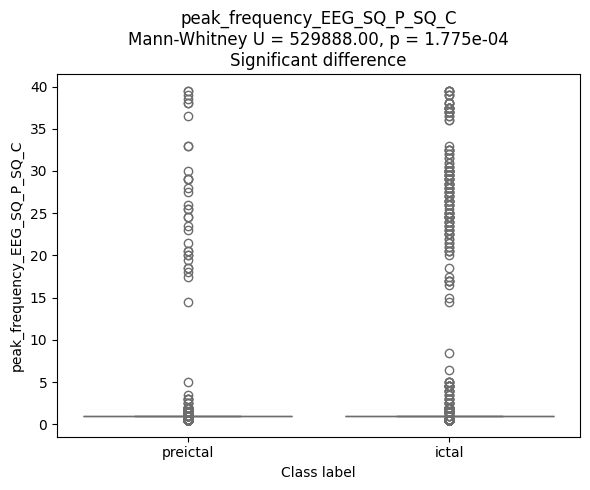

,feature,n_preictal,n_ictal,mannwhitney_U,p_value,result
23,theta_power_EEG_SQ_P_SQ_C,1047,1102,424911.0,4.068429e-26,Significant difference
10,var_EEG_SQ_P_SQ_C,1047,1102,429765.0,1.407388e-24,Significant difference
9,std_EEG_SQ_P_SQ_C,1047,1102,429765.0,1.407388e-24,Significant difference
11,rms_EEG_SQ_P_SQ_C,1047,1102,429768.0,1.410424e-24,Significant difference
24,alpha_power_EEG_SQ_P_SQ_C,1047,1102,432588.0,1.049302e-23,Significant difference
20,gamma_power_EEG_SQ_D_SQ_C,1047,1102,453043.0,7.042439e-18,Significant difference
13,line_length_EEG_SQ_P_SQ_C,1047,1102,453491.0,9.238806e-18,Significant difference
25,beta_power_EEG_SQ_P_SQ_C,1047,1102,459241.0,2.765627e-16,Significant difference
22,delta_power_EEG_SQ_P_SQ_C,1047,1102,459312.0,2.881329e-16,Significant difference
5,line_length_EEG_SQ_D_SQ_C,1047,1102,461074.0,7.906225e-16,Significant difference


In [34]:
import numpy as np

# -------------------------------
# Parameters
# -------------------------------
alpha = 0.05

# Colors for each class
palette = {
    "preictal": "skyblue",
    "ictal": "salmon"
}

# Store Mann-Whitney results
mannwhitney_results = []

# -------------------------------
# Loop through all feature columns
# -------------------------------
for feature in feature_cols:

    print(f"Plotting feature: {feature}")

    # -------------------------------
    # Extract values from both groups
    # -------------------------------
    preictal_values = group_1_PREICTAL[feature]
    ictal_values = group_2_SEIZURE[feature]

    # Convert to numeric and remove NaN / infinite values
    preictal_values = pd.to_numeric(preictal_values, errors="coerce")
    ictal_values = pd.to_numeric(ictal_values, errors="coerce")

    preictal_values = preictal_values.replace([np.inf, -np.inf], np.nan).dropna()
    ictal_values = ictal_values.replace([np.inf, -np.inf], np.nan).dropna()

    # -------------------------------
    # Skip feature if one group has no valid values
    # -------------------------------
    if len(preictal_values) == 0 or len(ictal_values) == 0:
        print(f"Skipping {feature}: not enough valid values")
        continue

    # -------------------------------
    # Create long-format dataframe for plotting
    # -------------------------------
    df_plot = pd.DataFrame({
        "value": pd.concat([preictal_values, ictal_values], axis=0),
        "label": (
            ["preictal"] * len(preictal_values) +
            ["ictal"] * len(ictal_values)
        )
    })

    # -------------------------------
    # Mann-Whitney U test
    # -------------------------------
    stat, p_value = mannwhitneyu(
        preictal_values,
        ictal_values,
        alternative="two-sided"
    )

    if p_value < alpha:
        test_result = "Significant difference"
    else:
        test_result = "No significant difference"

    # Save result
    mannwhitney_results.append({
        "feature": feature,
        "n_preictal": len(preictal_values),
        "n_ictal": len(ictal_values),
        "mannwhitney_U": stat,
        "p_value": p_value,
        "result": test_result
    })

    # -------------------------------
    # Boxplot
    # -------------------------------
    plt.figure(figsize=(6, 5))

    sns.boxplot(
        data=df_plot,
        x="label",
        y="value",
        hue="label",
        palette=palette,
        order=["preictal", "ictal"],
        legend=False
    )

    plt.title(
        f"{feature}\n"
        f"Mann-Whitney U = {stat:.2f}, p = {p_value:.3e}\n"
        f"{test_result}"
    )

    plt.xlabel("Class label")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

# -------------------------------
# Convert statistical results to dataframe
# -------------------------------
df_mannwhitney_results = pd.DataFrame(mannwhitney_results)

# Sort by p-value
df_mannwhitney_results = df_mannwhitney_results.sort_values("p_value")

df_mannwhitney_results

#### 3 Violin plots + Mann-W.

Plotting feature: mean_EEG_SQ_D_SQ_C


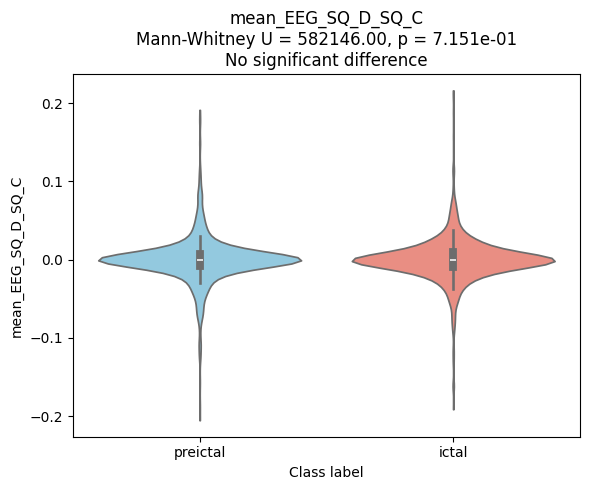

Plotting feature: std_EEG_SQ_D_SQ_C


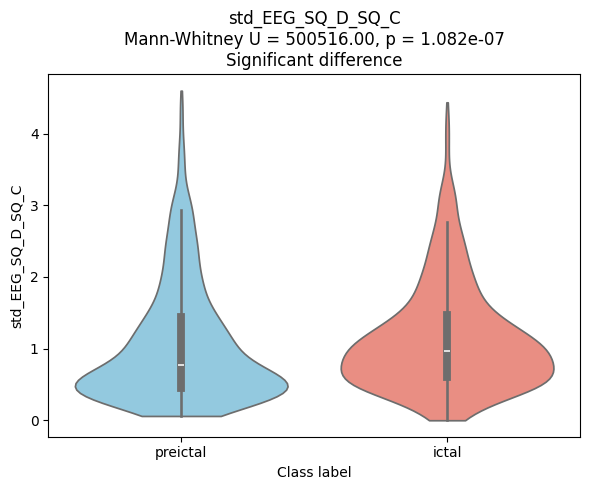

Plotting feature: var_EEG_SQ_D_SQ_C


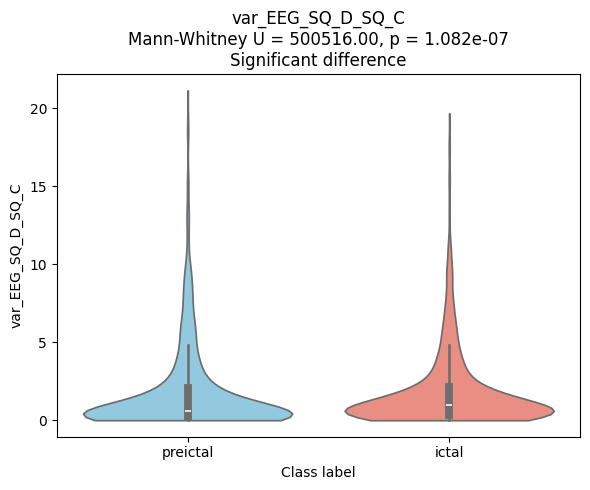

Plotting feature: rms_EEG_SQ_D_SQ_C


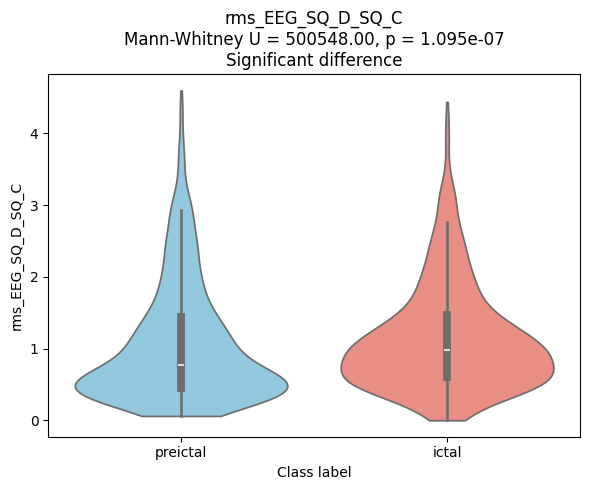

Plotting feature: ptp_EEG_SQ_D_SQ_C


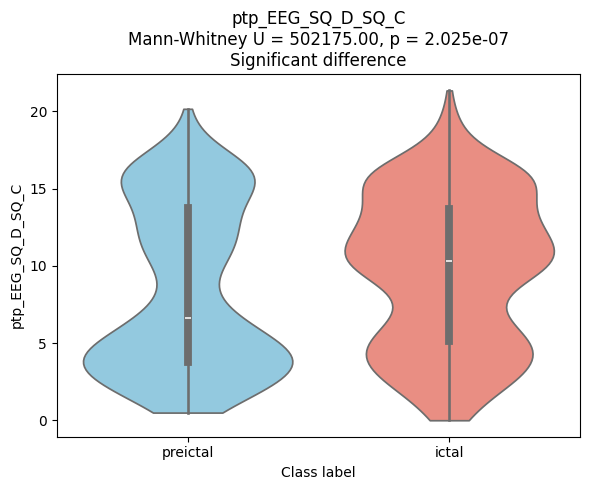

Plotting feature: line_length_EEG_SQ_D_SQ_C


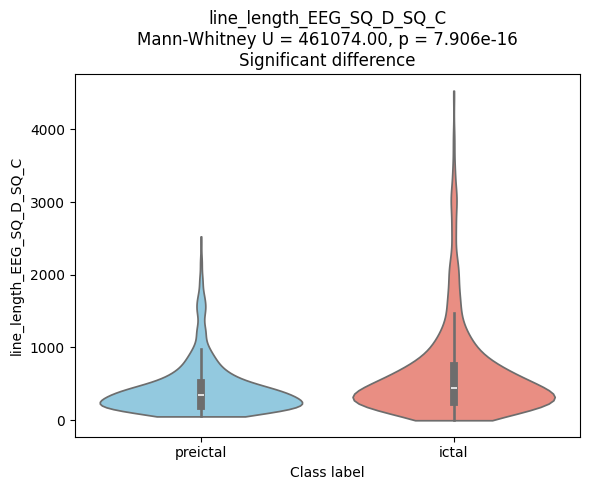

Plotting feature: skew_EEG_SQ_D_SQ_C


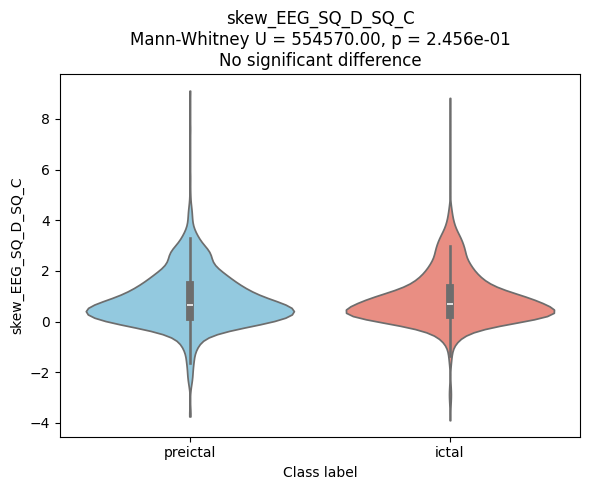

Plotting feature: kurtosis_EEG_SQ_D_SQ_C


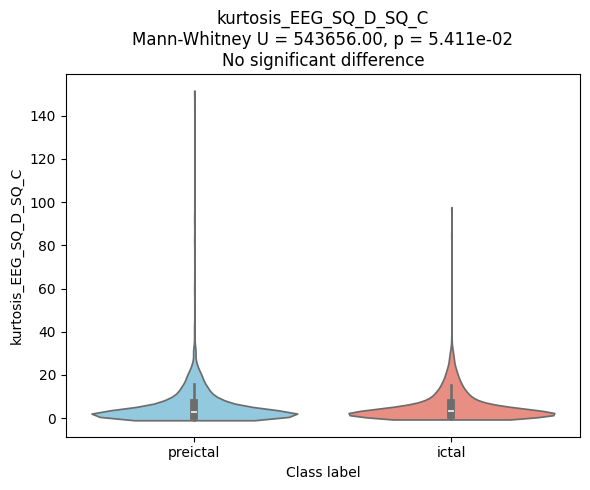

Plotting feature: mean_EEG_SQ_P_SQ_C


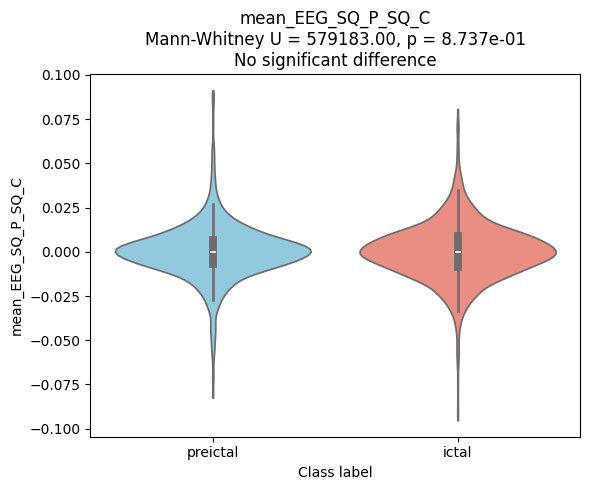

Plotting feature: std_EEG_SQ_P_SQ_C


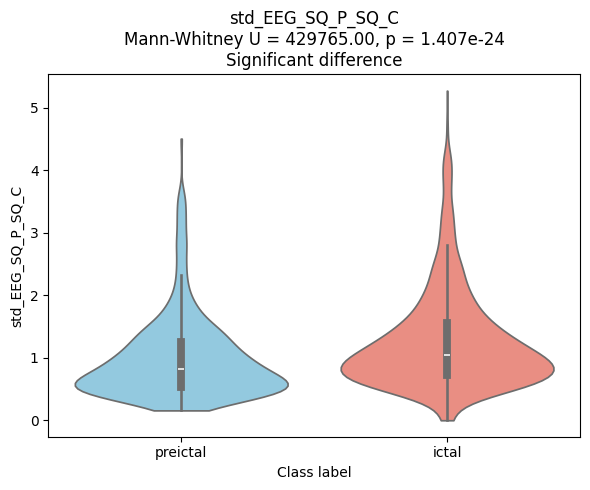

Plotting feature: var_EEG_SQ_P_SQ_C


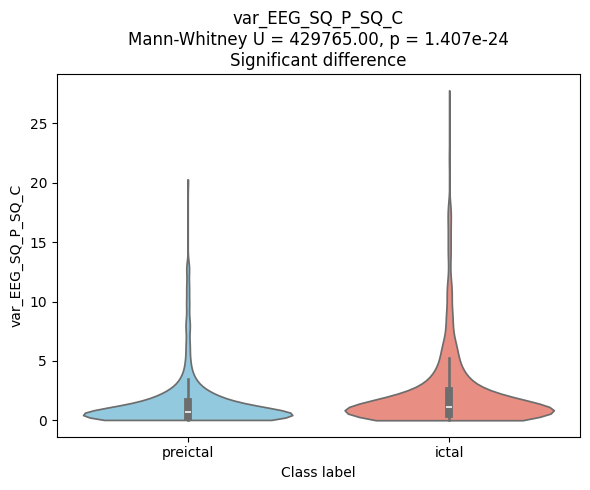

Plotting feature: rms_EEG_SQ_P_SQ_C


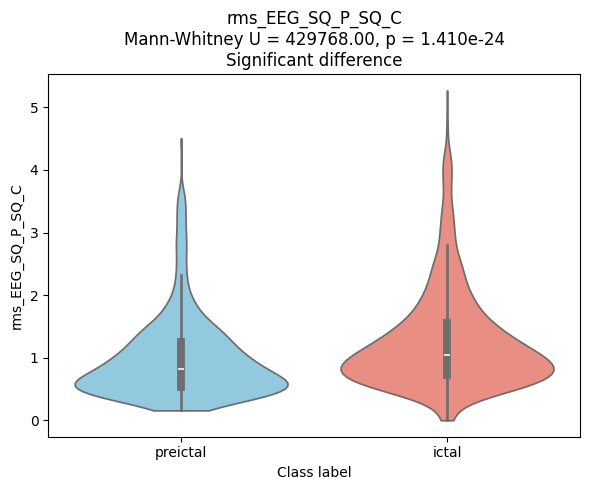

Plotting feature: ptp_EEG_SQ_P_SQ_C


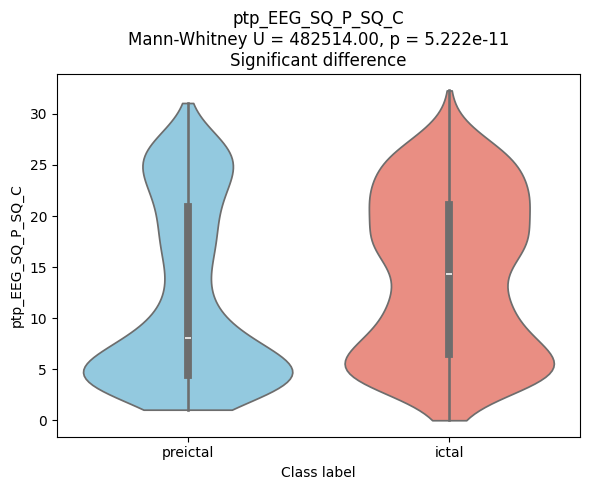

Plotting feature: line_length_EEG_SQ_P_SQ_C


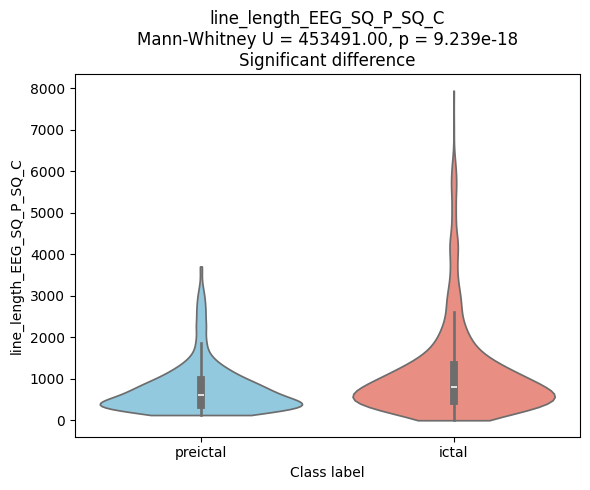

Plotting feature: skew_EEG_SQ_P_SQ_C


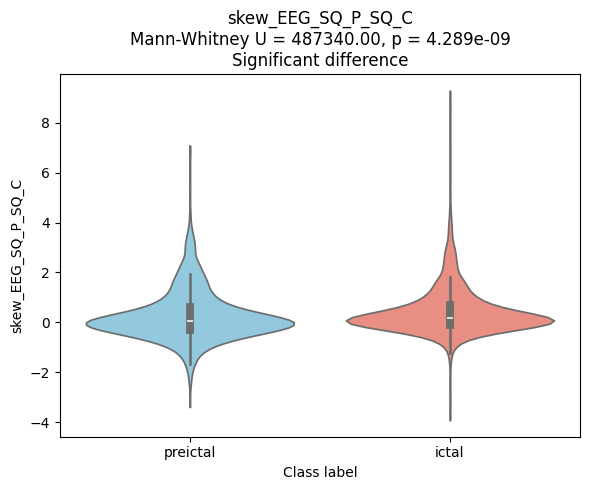

Plotting feature: kurtosis_EEG_SQ_P_SQ_C


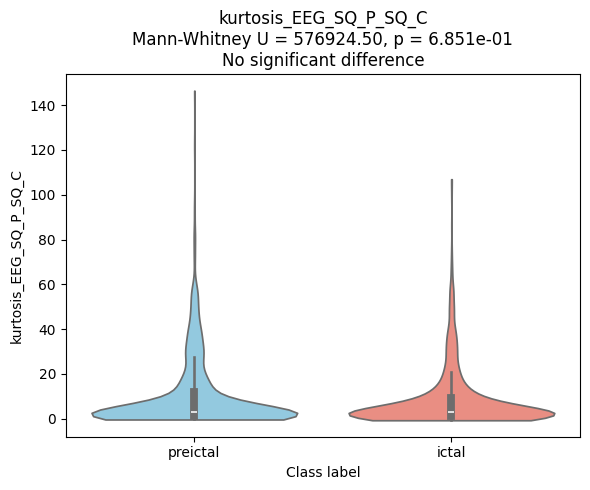

Plotting feature: delta_power_EEG_SQ_D_SQ_C


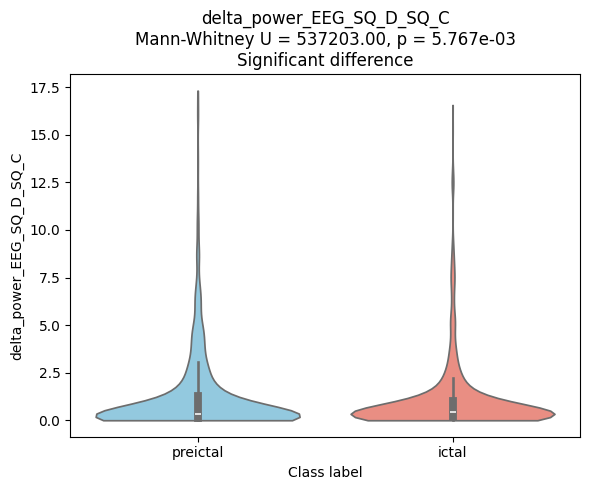

Plotting feature: theta_power_EEG_SQ_D_SQ_C


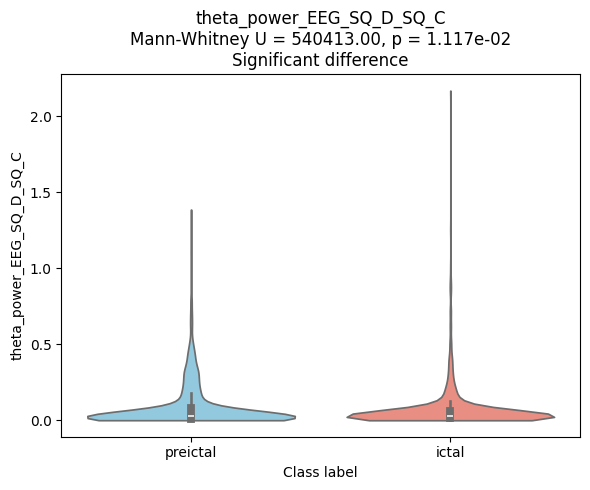

Plotting feature: alpha_power_EEG_SQ_D_SQ_C


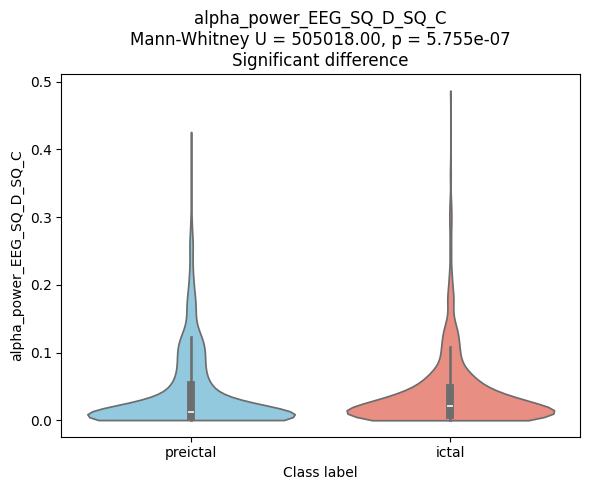

Plotting feature: beta_power_EEG_SQ_D_SQ_C


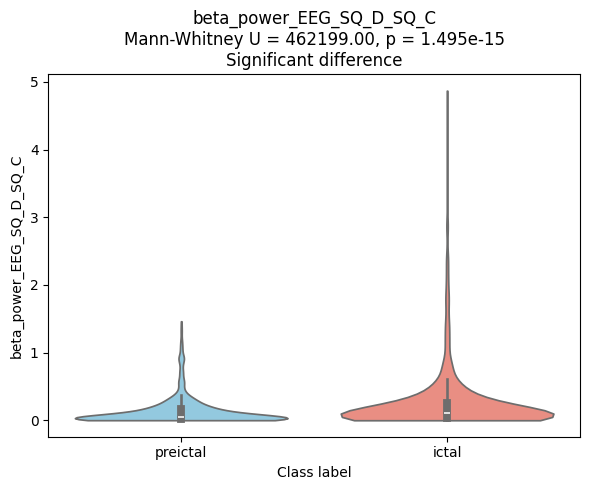

Plotting feature: gamma_power_EEG_SQ_D_SQ_C


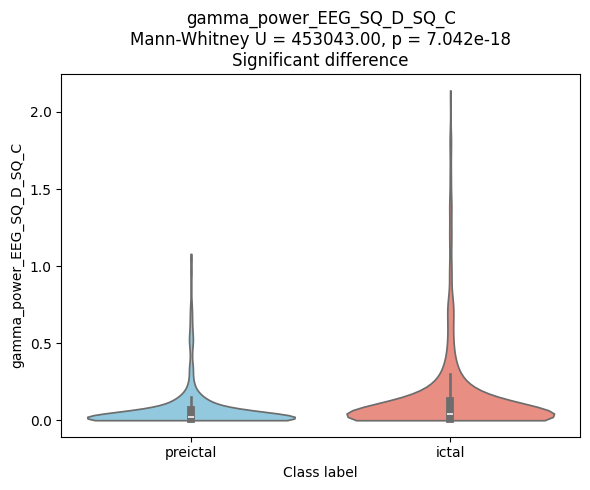

Plotting feature: peak_frequency_EEG_SQ_D_SQ_C


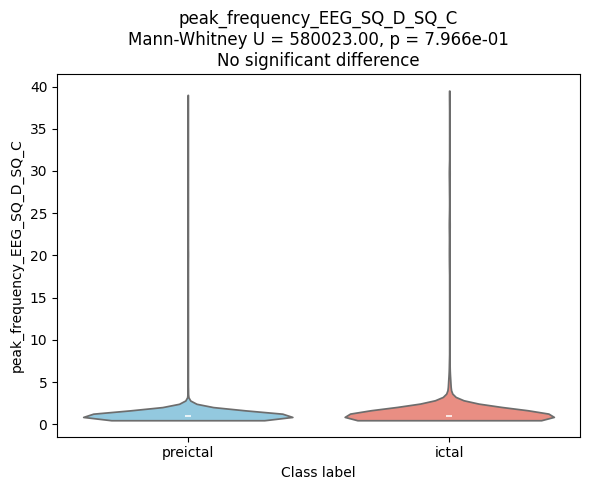

Plotting feature: delta_power_EEG_SQ_P_SQ_C


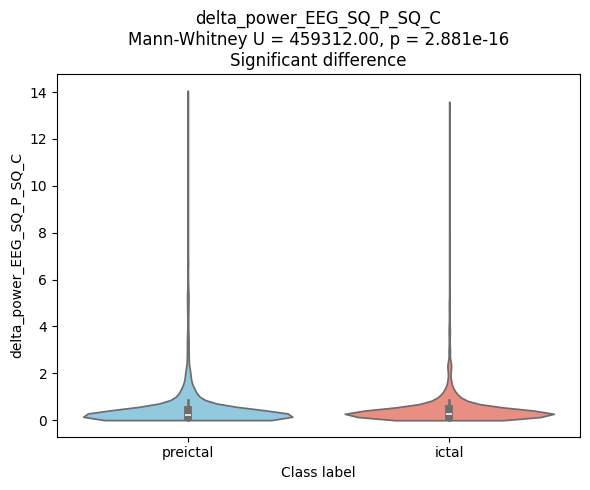

Plotting feature: theta_power_EEG_SQ_P_SQ_C


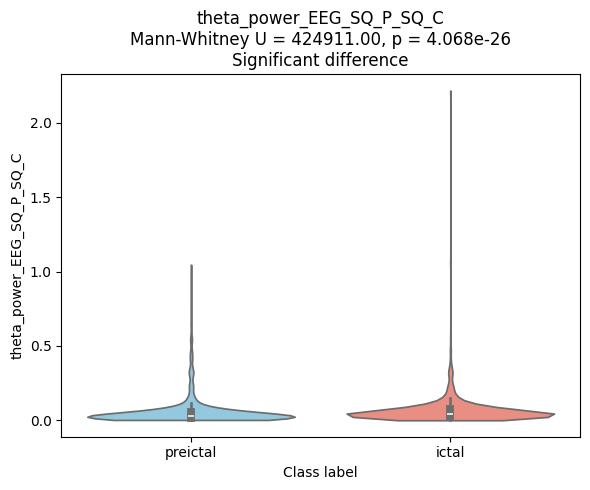

Plotting feature: alpha_power_EEG_SQ_P_SQ_C


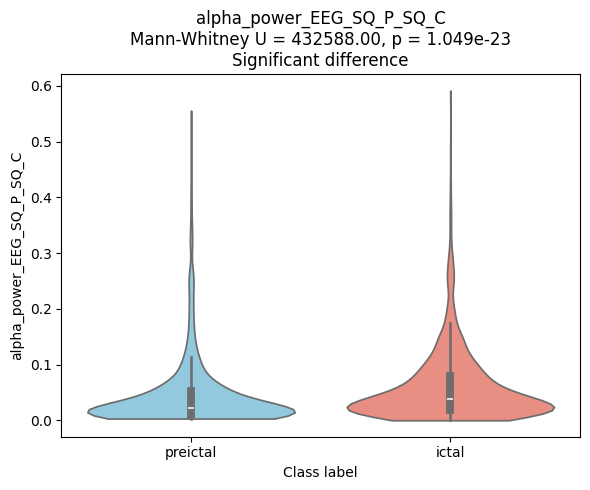

Plotting feature: beta_power_EEG_SQ_P_SQ_C


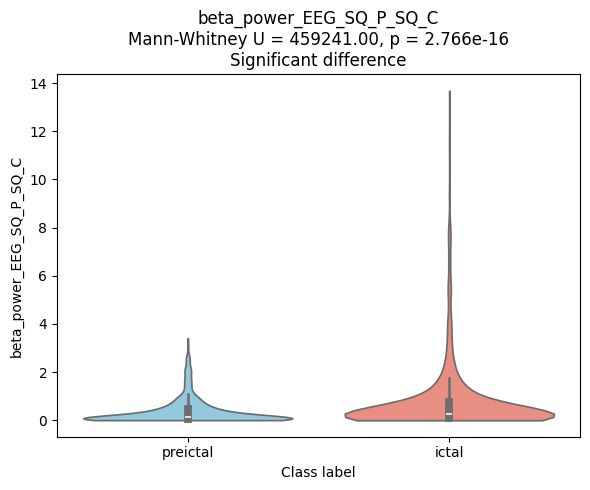

Plotting feature: gamma_power_EEG_SQ_P_SQ_C


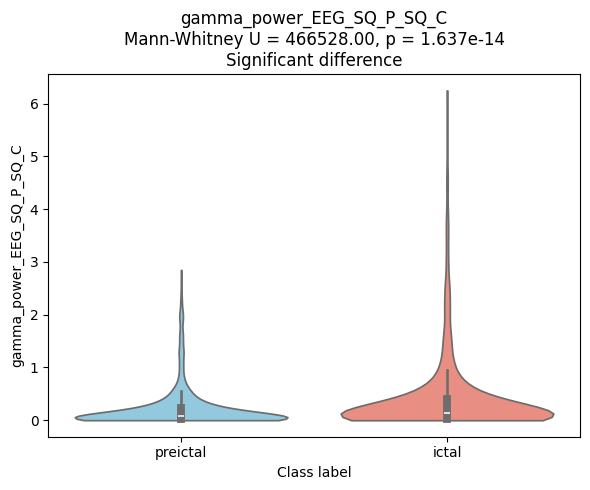

Plotting feature: peak_frequency_EEG_SQ_P_SQ_C


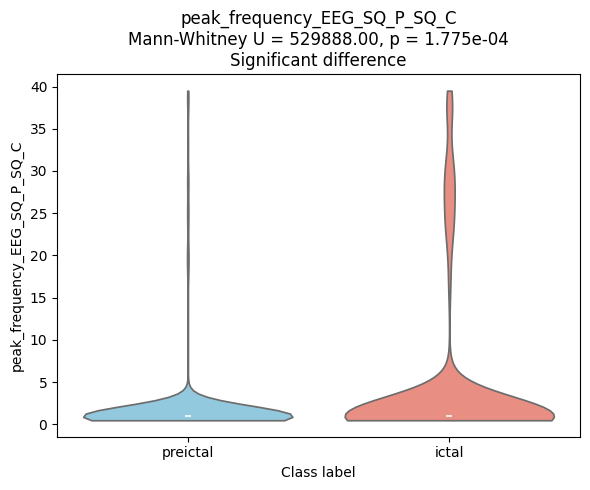

,feature,n_preictal,n_ictal,mannwhitney_U,p_value,result
23,theta_power_EEG_SQ_P_SQ_C,1047,1102,424911.0,4.068429e-26,Significant difference
10,var_EEG_SQ_P_SQ_C,1047,1102,429765.0,1.407388e-24,Significant difference
9,std_EEG_SQ_P_SQ_C,1047,1102,429765.0,1.407388e-24,Significant difference
11,rms_EEG_SQ_P_SQ_C,1047,1102,429768.0,1.410424e-24,Significant difference
24,alpha_power_EEG_SQ_P_SQ_C,1047,1102,432588.0,1.049302e-23,Significant difference
20,gamma_power_EEG_SQ_D_SQ_C,1047,1102,453043.0,7.042439e-18,Significant difference
13,line_length_EEG_SQ_P_SQ_C,1047,1102,453491.0,9.238806e-18,Significant difference
25,beta_power_EEG_SQ_P_SQ_C,1047,1102,459241.0,2.765627e-16,Significant difference
22,delta_power_EEG_SQ_P_SQ_C,1047,1102,459312.0,2.881329e-16,Significant difference
5,line_length_EEG_SQ_D_SQ_C,1047,1102,461074.0,7.906225e-16,Significant difference


In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# -------------------------------
# Parameters
# -------------------------------
alpha = 0.05

# Colors for each class
palette = {
    "preictal": "skyblue",
    "ictal": "salmon"
}

# Store Mann-Whitney results
mannwhitney_results_violin = []

# -------------------------------
# Loop through all feature columns
# -------------------------------
for feature in feature_cols:

    print(f"Plotting feature: {feature}")

    # -------------------------------
    # Extract values from both groups
    # -------------------------------
    preictal_values = group_1_PREICTAL[feature]
    ictal_values = group_2_SEIZURE[feature]

    # Convert to numeric and remove NaN / infinite values
    preictal_values = pd.to_numeric(preictal_values, errors="coerce")
    ictal_values = pd.to_numeric(ictal_values, errors="coerce")

    preictal_values = preictal_values.replace([np.inf, -np.inf], np.nan).dropna()
    ictal_values = ictal_values.replace([np.inf, -np.inf], np.nan).dropna()

    # -------------------------------
    # Skip feature if one group has no valid values
    # -------------------------------
    if len(preictal_values) == 0 or len(ictal_values) == 0:
        print(f"Skipping {feature}: not enough valid values")
        continue

    # -------------------------------
    # Create long-format dataframe for plotting
    # -------------------------------
    df_plot = pd.DataFrame({
        "value": pd.concat([preictal_values, ictal_values], axis=0),
        "label": (
            ["preictal"] * len(preictal_values) +
            ["ictal"] * len(ictal_values)
        )
    })

    # -------------------------------
    # Mann-Whitney U test
    # -------------------------------
    stat, p_value = mannwhitneyu(
        preictal_values,
        ictal_values,
        alternative="two-sided"
    )

    if p_value < alpha:
        test_result = "Significant difference"
    else:
        test_result = "No significant difference"

    # Save result
    mannwhitney_results_violin.append({
        "feature": feature,
        "n_preictal": len(preictal_values),
        "n_ictal": len(ictal_values),
        "mannwhitney_U": stat,
        "p_value": p_value,
        "result": test_result
    })

    # -------------------------------
    # Violin plot
    # -------------------------------
    plt.figure(figsize=(6, 5))

    sns.violinplot(
        data=df_plot,
        x="label",
        y="value",
        hue="label",
        palette=palette,
        order=["preictal", "ictal"],
        legend=False,
        inner="box",
        cut=0
    )

    plt.title(
        f"{feature}\n"
        f"Mann-Whitney U = {stat:.2f}, p = {p_value:.3e}\n"
        f"{test_result}"
    )

    plt.xlabel("Class label")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

# -------------------------------
# Convert statistical results to dataframe
# -------------------------------
df_mannwhitney_results_violin = pd.DataFrame(mannwhitney_results_violin)

# Sort by p-value
df_mannwhitney_results_violin = df_mannwhitney_results_violin.sort_values("p_value")

df_mannwhitney_results_violin